## Data Mining with AWS S3 and Python

**1. Dataset description**

- **What dataset you chose and why**

### Dataset of choice:

Titanic Dataset from Kaggle

link - https://www.kaggle.com/datasets/yasserh/titanic-dataset

### Dataset description

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

### The reason for choosing this datset:

Its a good dataset that's a good combination of numerical values, text values and categorical values spread across the columns: 'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'E,barked', I'll be able to perform the ncessary steps of data processing like handling missing values, visualization, feature engineering and so forth on this dataset.



### 2. AWS S3 Steps

- **Bucket creation**
- **Dataset upload**

Step 1: Creating a Free Tier Account

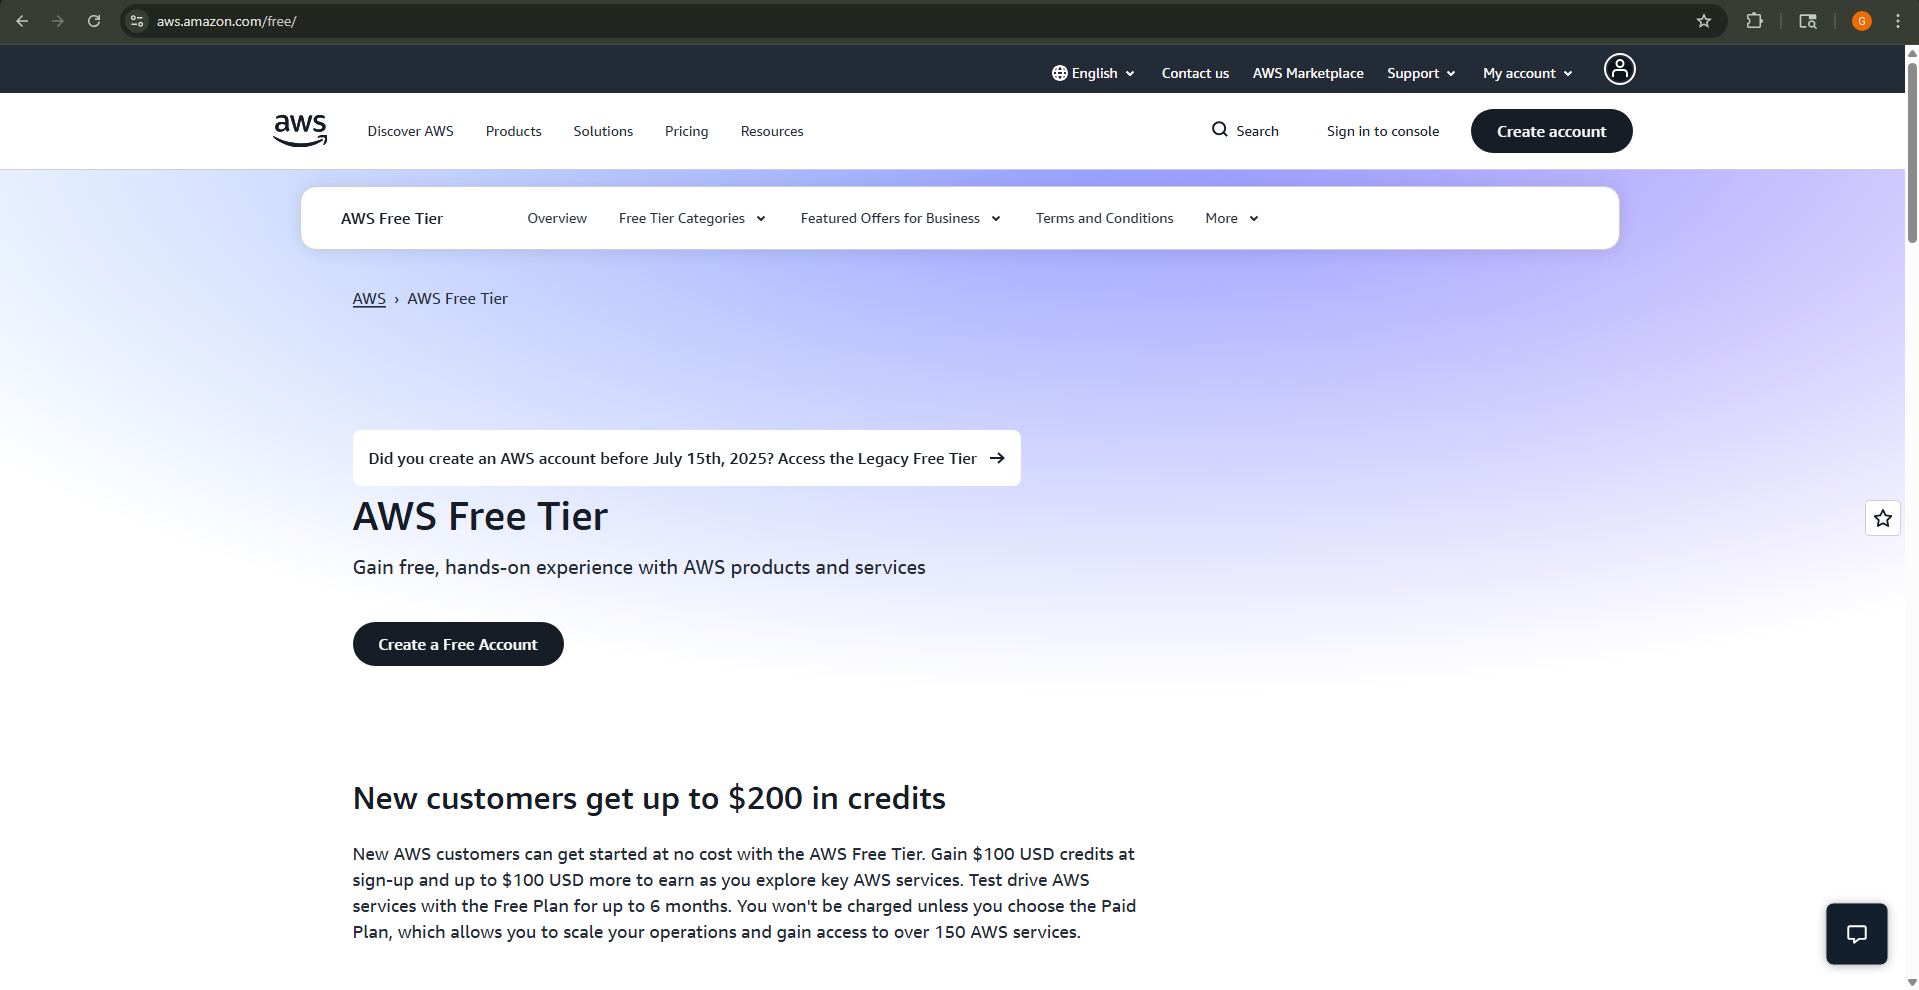

Step 2: Creating a S3 Bucket

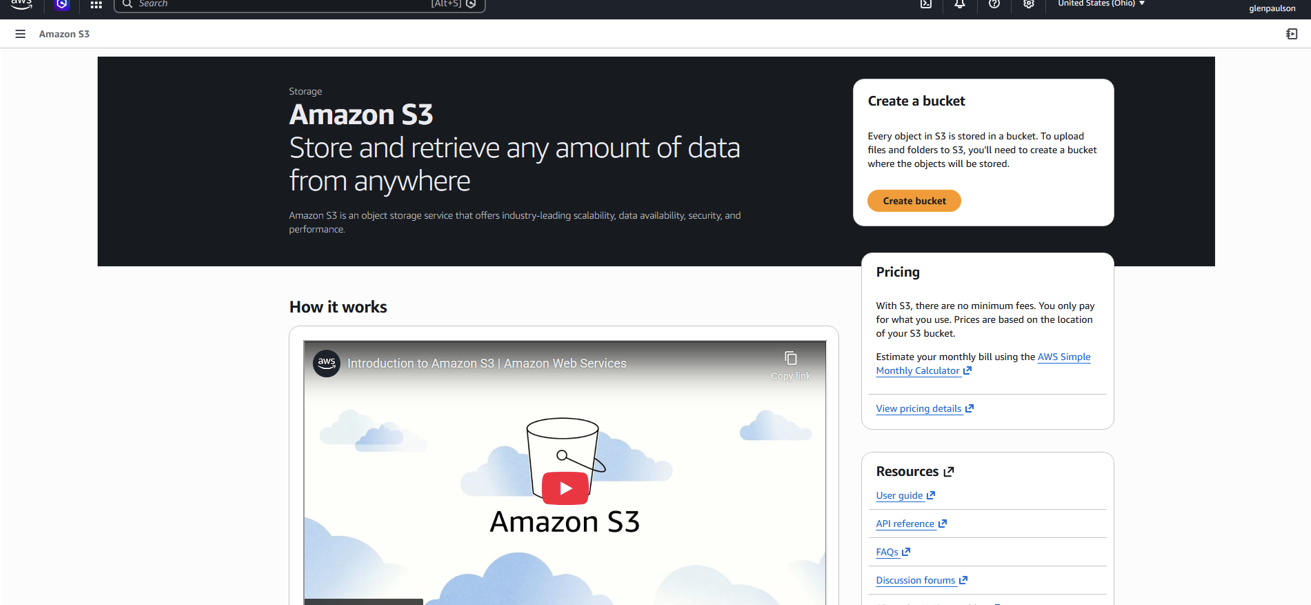

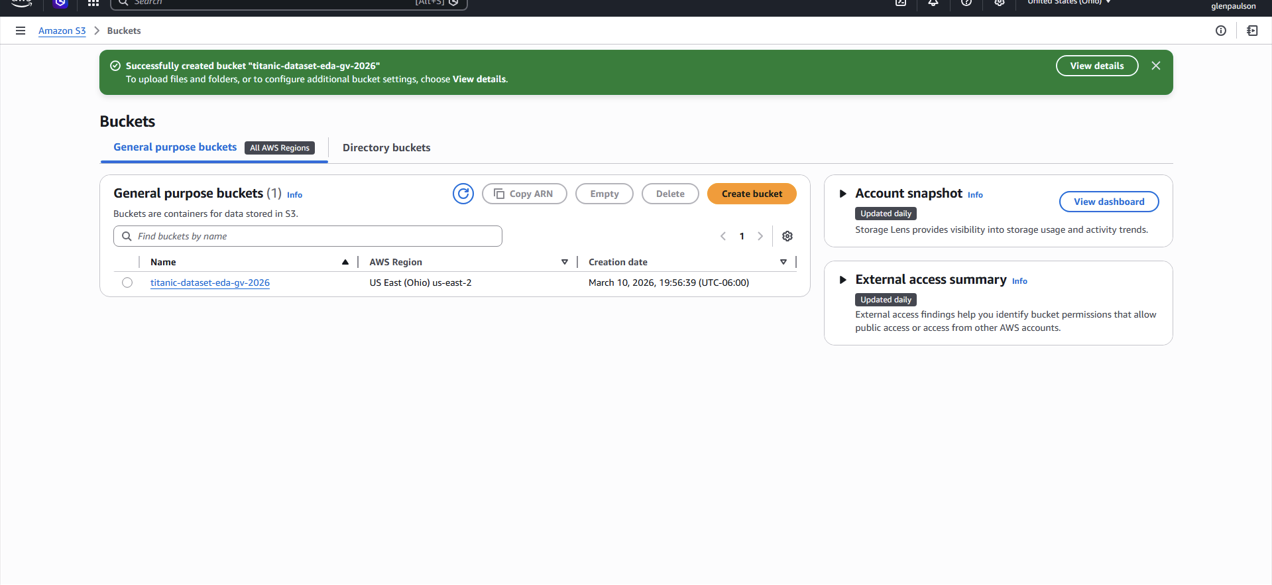

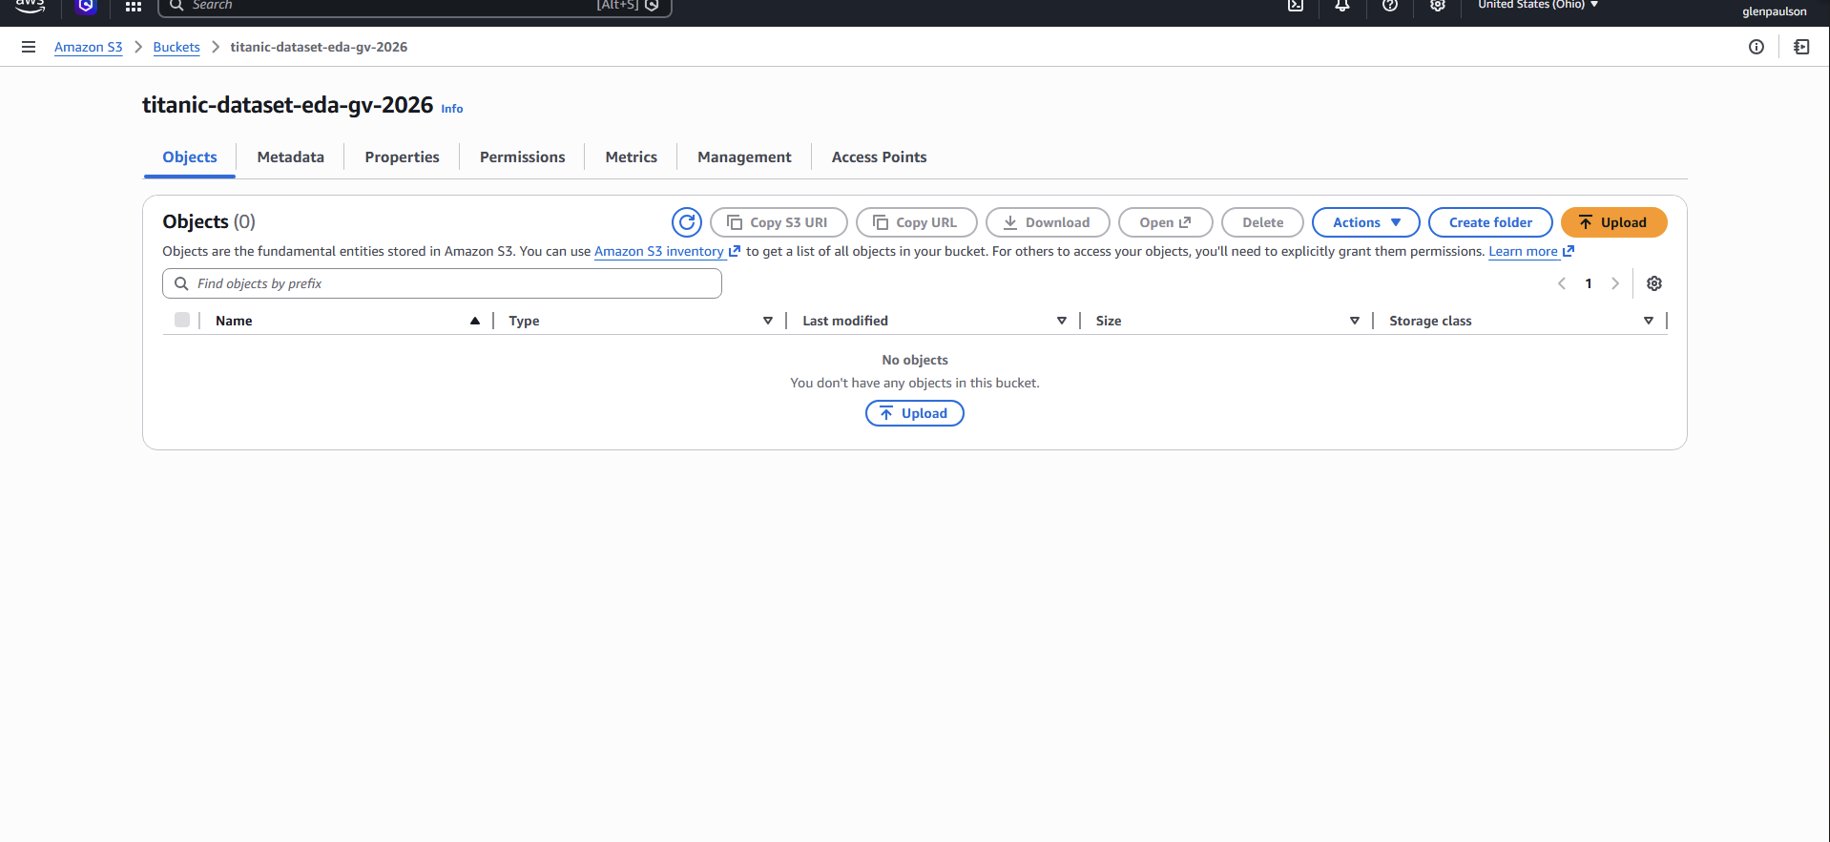

### Uploading the titanic dataset

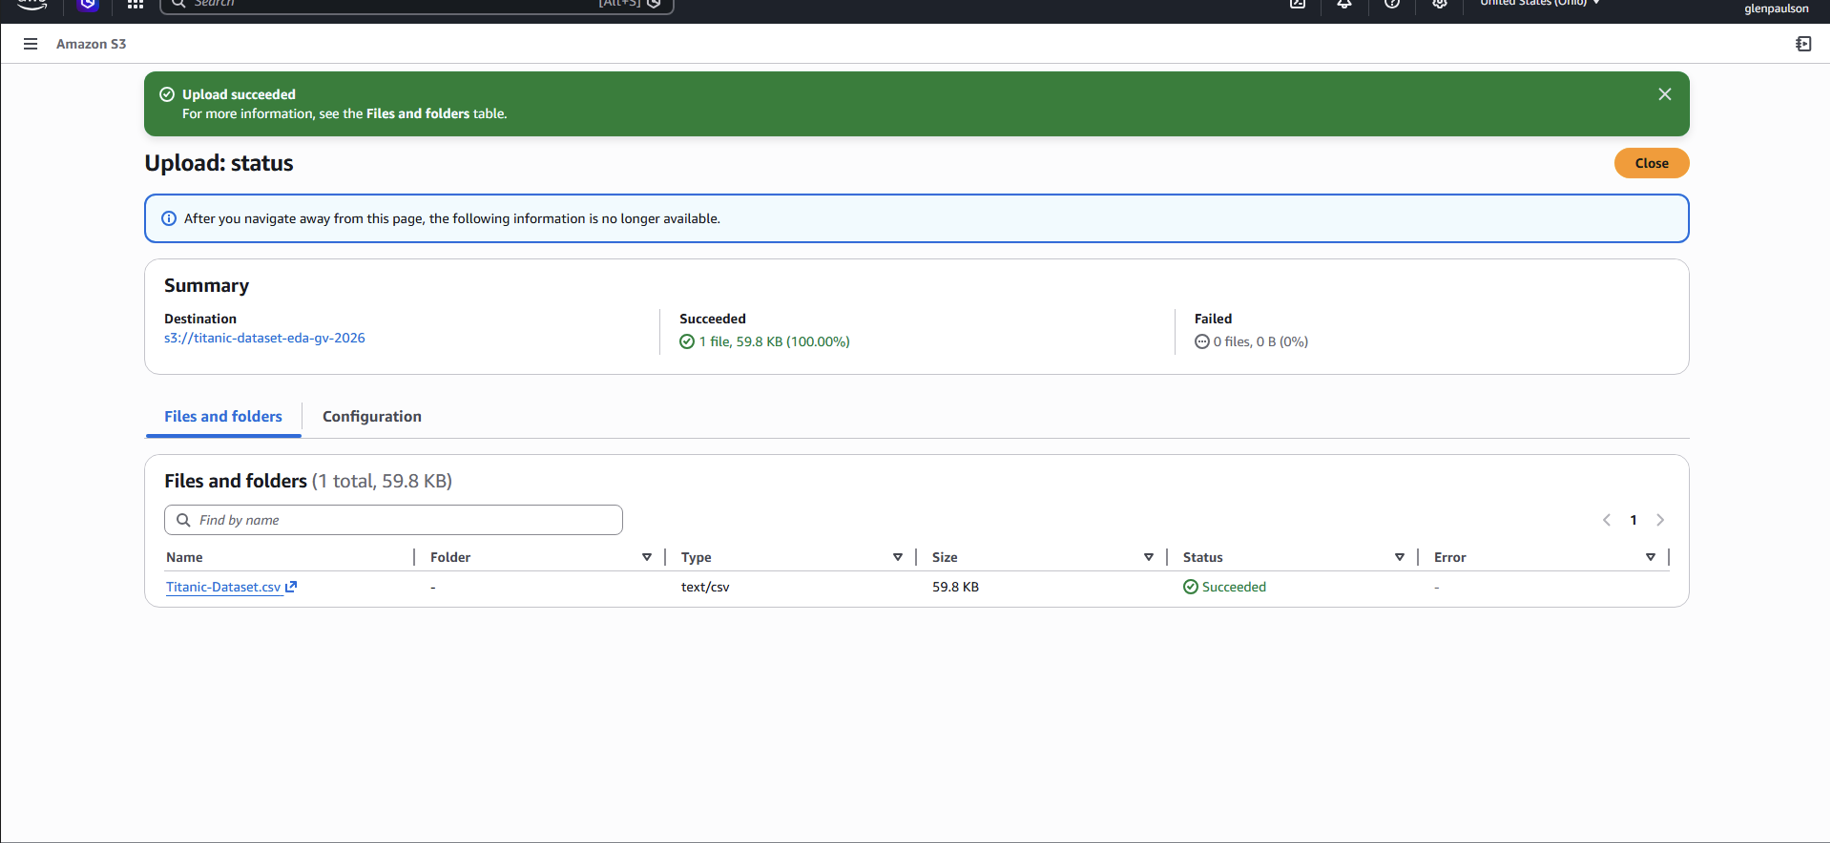

### Generate Access Key

after creating a user under IAM

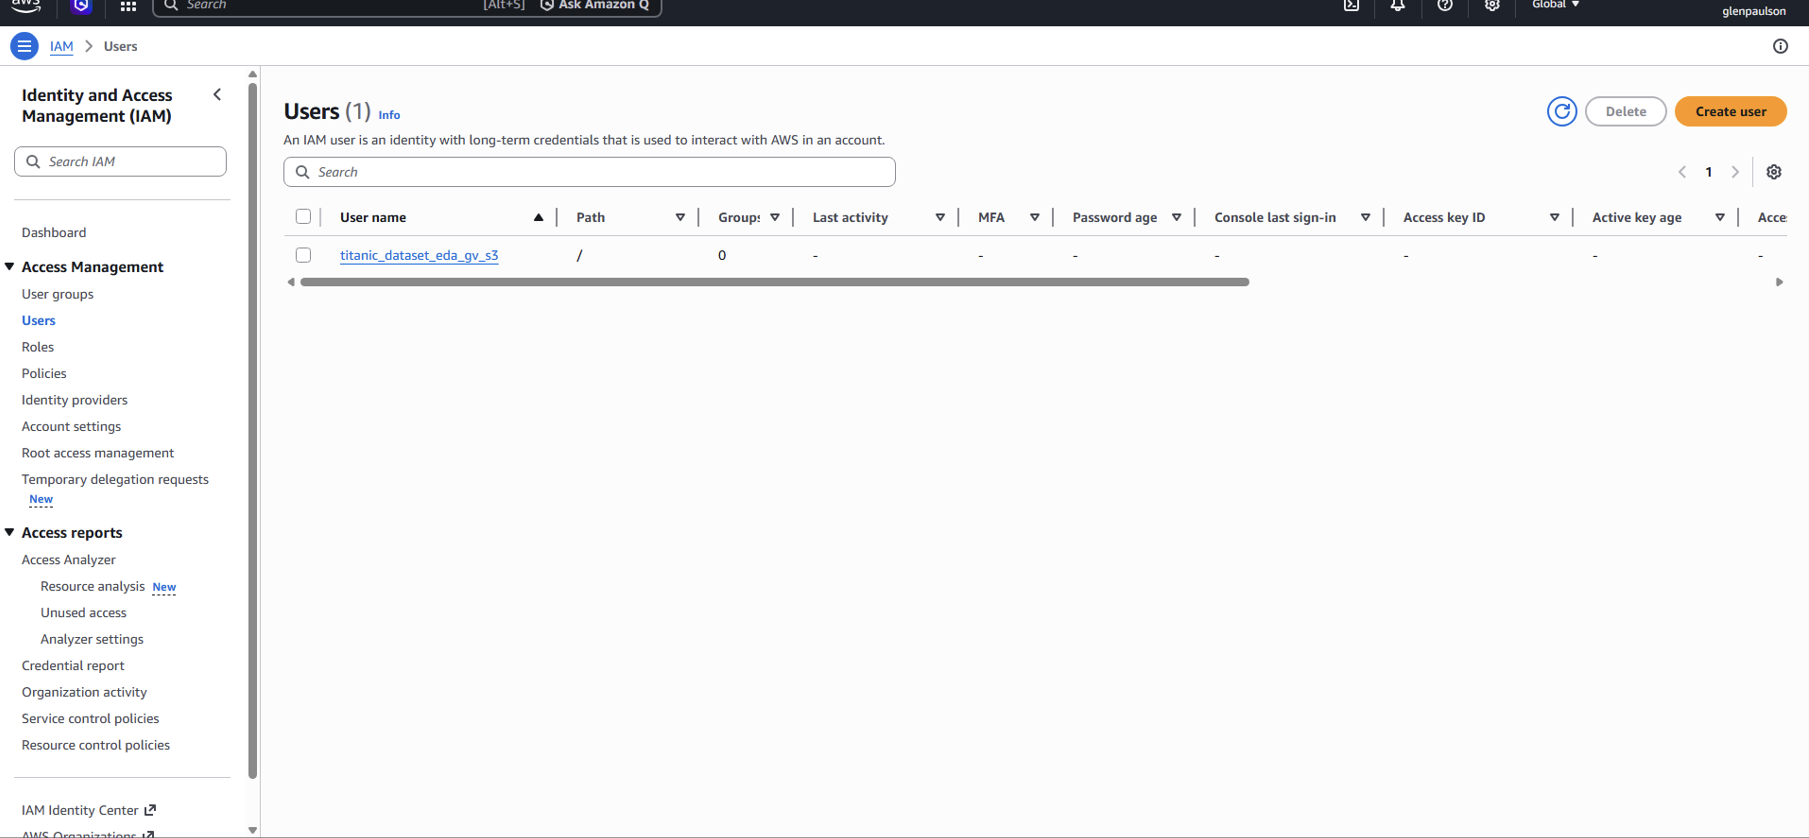



---



## Connecting to AWS S3 Bucket

- **3. Accessing the dataset from Python**



In [71]:
!pip install boto3

In [72]:
import pandas as pd
import boto3
from io import BytesIO
from google.colab import userdata

# Loading credentials from Colab Secrets
AWS_ACCESS_KEY = userdata.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_KEY = userdata.get('AWS_SECRET_ACCESS_KEY')

# Your S3 details
BUCKET_NAME = 'titanic-dataset-eda-gv-2026'
FILE_KEY = 'Titanic-Dataset.csv'

try:
    # initalizing the s3 client
    s3_client = boto3.client(
        's3',
        aws_access_key_id=AWS_ACCESS_KEY,
        aws_secret_access_key=AWS_SECRET_KEY,
        region_name='us-east-1'
    )

    # fetching the response
    response = s3_client.get_object(Bucket=BUCKET_NAME, Key=FILE_KEY)

    # reading into df
    df = pd.read_csv(BytesIO(response['Body'].read()))
    print("loading dataset from AWS S3 successfull")

except Exception as e:
    print(f"loading failed with error: {e}")

print(df.info())
df.head()

loading dataset from AWS S3 successfull
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **4. Data cleaning and transformation steps**

here I'm going to handle the missing values, remove duplicate rows, work on new features and update category columns into numeric values.

In [73]:
df = df.drop_duplicates() # dropping the duplicates

print("num of missing values per column before: \n", df.isna().sum(), "\n") # checking if we've missing values per column

df['Age'] = df['Age'].fillna(df['Age'].median()) # filling the missing Age values with the median

# I can see that we've too many missing values under the cabin column, so I'm dropping it
df = df.drop(columns=['Cabin'])

# I'll fill the missimg Embarked value with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# we can create a new feature column by combining the SibSp and Parch and adding the passenger to form a feature called FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# I'll also transform the 'Sex' category column into numberic 1s and 0s
df['Sex_Updated'] = df['Sex'].map({'male': 0, 'female': 1})

# we can also extract one key insight based on family size, if its 1 then it means the passenger is alone
df['IsPassengerAlone'] = (df['FamilySize'] == 1).astype(int)

print("num of missing values per column after: \n", df.isna().sum(), "\n")
print(df.info(), "\n")
df.head()

num of missing values per column before: 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64 

num of missing values per column after: 
 PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                0
Embarked            0
FamilySize          0
Sex_Updated         0
IsPassengerAlone    0
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PassengerId       891 non-null    int64  
 1   Survived          891 non-null    int64  
 2   Pclass            891 non-null    int64  
 3   Name

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,Sex_Updated,IsPassengerAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0,1


### 5. Exploratory analysis and visualizations

In [74]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_Updated,IsPassengerAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,1.904602,0.352413,0.602694
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,1.613459,0.477990,0.489615
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,2.000000,1.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,1.000000,1.000000


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
print("basic statistics: \n\n")

print(f"total passengers: {len(df)}")
print(f"average age: {df['Age'].mean()}")
print(f"average fare: {df['Fare'].mean()}")
print(f"average family size: {df['FamilySize'].mean()}")
print(f"survival rate: {df['Survived'].mean() * 100}%")

print("\nsurvival counts \n")
print(df['Survived'].value_counts().rename({0: "didn't survive", 1: "did survive"}))

print("\ngender distribution \n")
print(df['Sex'].value_counts())

basic statistics: 


total passengers: 891
average age: 29.36158249158249
average fare: 32.204207968574636
average family size: 1.904601571268238
survival rate: 38.38383838383838%

survival counts 

Survived
didn't survive    549
did survive       342
Name: count, dtype: int64

gender distribution 

Sex
male      577
female    314
Name: count, dtype: int64


### Survival rate by gender

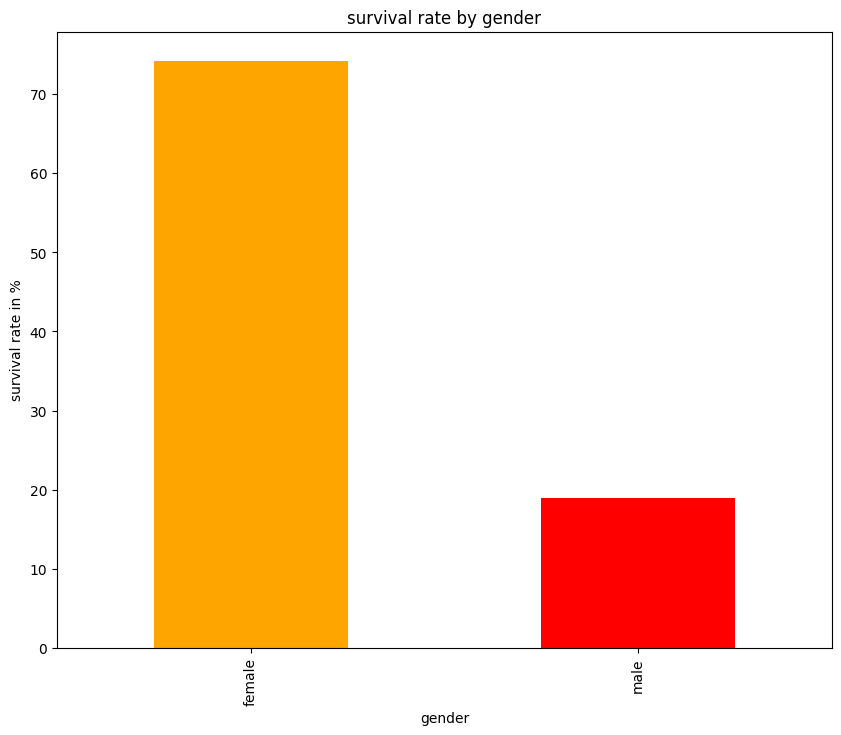

In [77]:
plt.figure(figsize=(10,8))
survival_counts = df.groupby('Sex')['Survived'].mean() * 100
survival_counts.plot(kind='bar', color=['orange', 'red'])
plt.title('survival rate by gender')
plt.xlabel('gender')
plt.ylabel('survival rate in %')
plt.show()

The above bar chart shows that the females had a higher survival rate at almost 74%. This is pretty clear from the evacuation protocols where women and children are led to safety first.

### Survival rate by passenger class

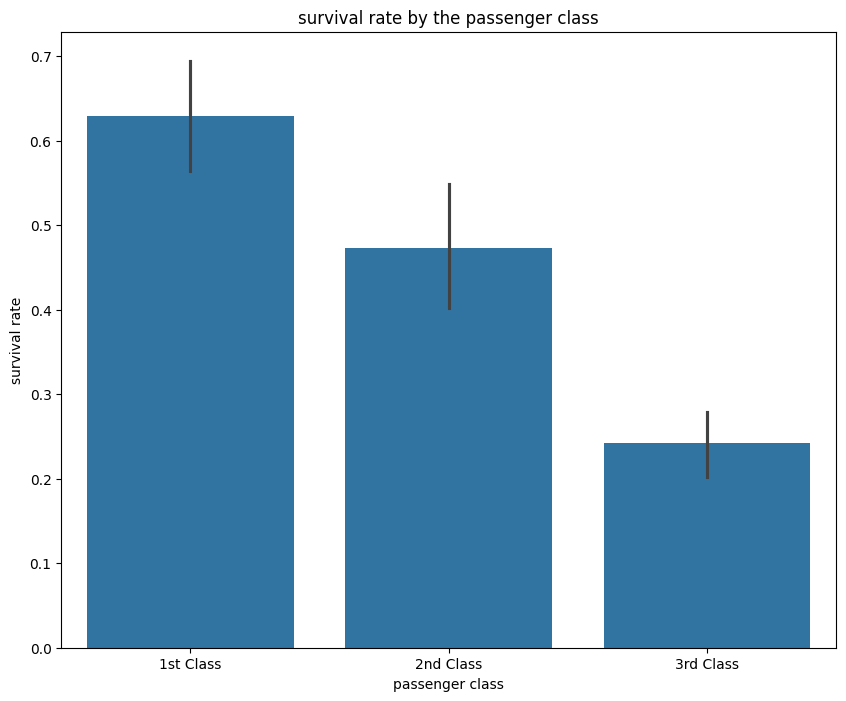

In [78]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('survival rate by the passenger class')
plt.xlabel('passenger class')
plt.ylabel('survival rate')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.show()

The above bar chart shows that the 1st class passengers had the highest survival rate at almost 63%. Which could imply they had a higher preference during the evacuation.

### Age distribution according to survival status

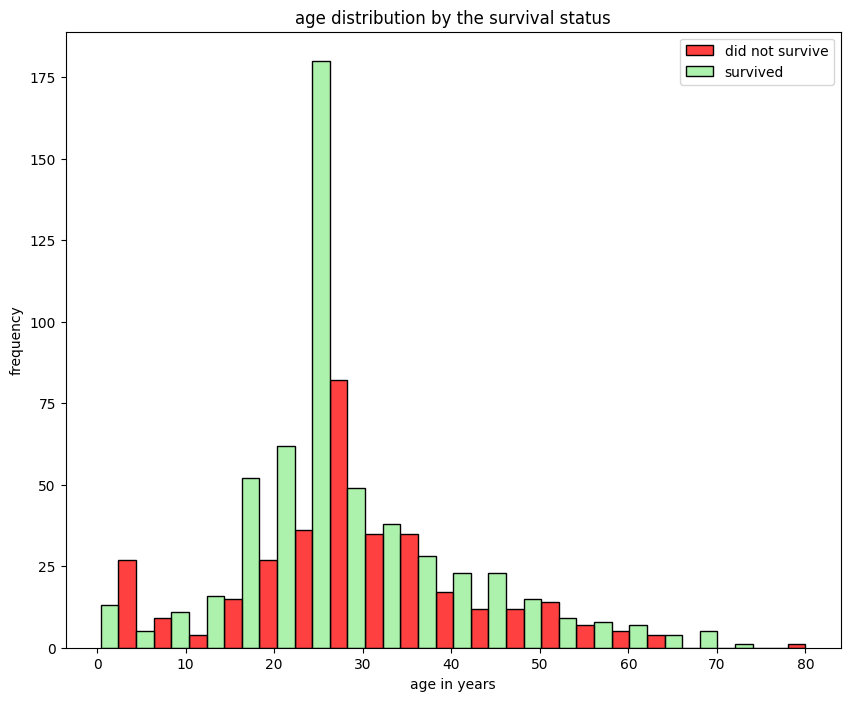

In [79]:
plt.figure(figsize=(10, 8))
sns.histplot(data=df, x='Age', hue='Survived', bins=20, multiple='dodge', palette=['lightgreen', 'red'])
plt.title('age distribution by the survival status')
plt.xlabel('age in years')
plt.ylabel('frequency')
plt.legend(labels=['did not survive', 'survived'])
plt.show()

**Explanation:**

From the above plot we can see that the Children under 10 has a better survival rate than the other age groups even though in terms of absolute numbers more children died than survived.

Older passengers of 60+ shows lower survival rates.

Based on the analysis we can also say that the men in the age group of 20-35 mostly from the third class who are predominantly workers had lower survival rate.

We see a spike around age 25 - 30 resulting from filling missing age values with the median during data cleaning.

### Survival rate by the family size

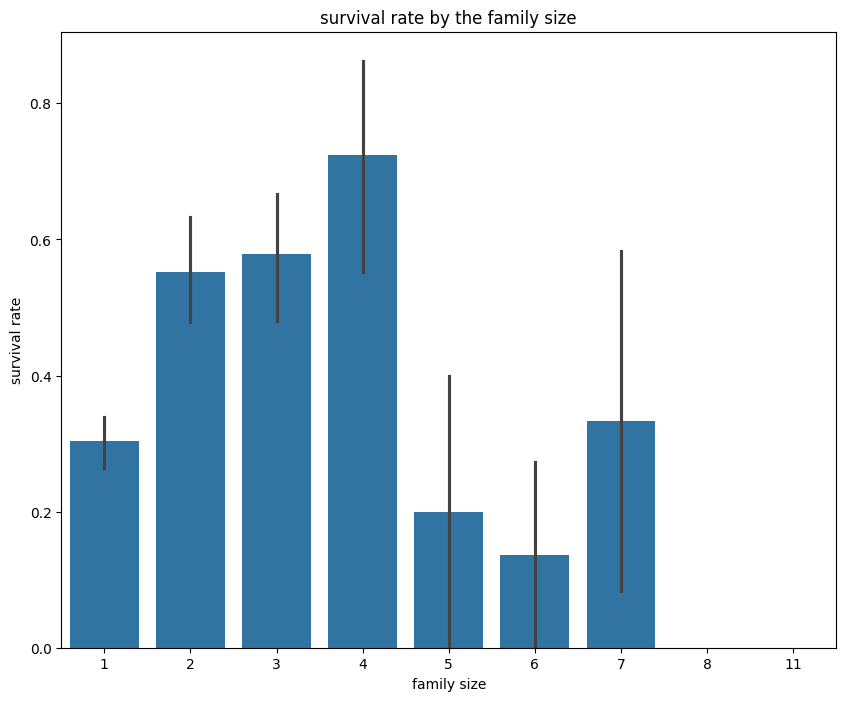

In [80]:
plt.figure(figsize=(10, 8))
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('survival rate by the family size')
plt.xlabel('family size')
plt.ylabel('survival rate')
plt.show()

The above plot shows that families with a size of 2-4 had a higher chance of survival, which could mean that being in a small group improves the chances of survival.

## 6. Key Insights and Conclusions

#### 1. **The social and economic status clearly has an influence on the sirvival rate**
- First-class passengers had a 63% survival rate compared to only 24% for third-class passengers
- This had to do with getting special preference during evacuation and having cabings closer to the evacuation corridors.

#### 2. **Gender played a key role in the survival rate**
- Female passengers: ~74% survival rate
- Male passengers: ~19% survival rate  
- This can be attributed to the fact that women and children are given preference during the evacuation process.

#### 3. **Age plays a crucial role in the survival rate as well**
- as we saw in the distribution, children had a better survival rate than the third class male workers.

#### 4. **Being in a smaller family group increased the survival chances**
- Small families (2-4 members) had the highest survival rates (50-70%)


### Conclusion

The data collected has been really crucial in understanding the patterns and insights on what predictors mattered towards the survival of passengers. Adding a new feature of family size also gave us additional insights to add to the existing list of predictor insights. This clearly shows how the data, especially in this case a historical dataset from the Titanic disaster tells us a story on what all factors came into the picture in deciding a passenger's survival rate.

